In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("flipkart_com-ecommerce_sample.csv")

print(df.head())
print(df.info())

                            uniq_id            crawl_timestamp  \
0  c2d766ca982eca8304150849735ffef9  2016-03-25 22:59:23 +0000   
1  7f7036a6d550aaa89d34c77bd39a5e48  2016-03-25 22:59:23 +0000   
2  f449ec65dcbc041b6ae5e6a32717d01b  2016-03-25 22:59:23 +0000   
3  0973b37acd0c664e3de26e97e5571454  2016-03-25 22:59:23 +0000   
4  bc940ea42ee6bef5ac7cea3fb5cfbee7  2016-03-25 22:59:23 +0000   

                                         product_url  \
0  http://www.flipkart.com/alisha-solid-women-s-c...   
1  http://www.flipkart.com/fabhomedecor-fabric-do...   
2  http://www.flipkart.com/aw-bellies/p/itmeh4grg...   
3  http://www.flipkart.com/alisha-solid-women-s-c...   
4  http://www.flipkart.com/sicons-all-purpose-arn...   

                            product_name  \
0    Alisha Solid Women's Cycling Shorts   
1    FabHomeDecor Fabric Double Sofa Bed   
2                             AW Bellies   
3    Alisha Solid Women's Cycling Shorts   
4  Sicons All Purpose Arnica Dog Shampoo   

 

In [3]:
# Convert price columns to numeric
df['retail_price'] = pd.to_numeric(df['retail_price'], errors='coerce')
df['discounted_price'] = pd.to_numeric(df['discounted_price'], errors='coerce')

# Remove null values
df = df.dropna(subset=['retail_price', 'discounted_price'])

print(df.isnull().sum())

uniq_id                       0
crawl_timestamp               0
product_url                   0
product_name                  0
product_category_tree         0
pid                           0
retail_price                  0
discounted_price              0
image                         3
is_FK_Advantage_product       0
description                   2
product_rating                0
overall_rating                0
brand                      5851
product_specifications       12
dtype: int64


In [4]:
# Average price
print("Average Retail Price:", np.mean(df['retail_price']))

# Max price
print("Max Price:", np.max(df['retail_price']))

# Min price
print("Min Price:", np.min(df['retail_price']))

Average Retail Price: 2979.2061038048387
Max Price: 571230.0
Min Price: 35.0


In [5]:
df['discount_percent'] = ((df['retail_price'] - df['discounted_price']) / df['retail_price']) * 100

print(df[['retail_price', 'discounted_price', 'discount_percent']].head())

   retail_price  discounted_price  discount_percent
0         999.0             379.0         62.062062
1       32157.0           22646.0         29.576764
2         999.0             499.0         50.050050
3         699.0             267.0         61.802575
4         220.0             210.0          4.545455


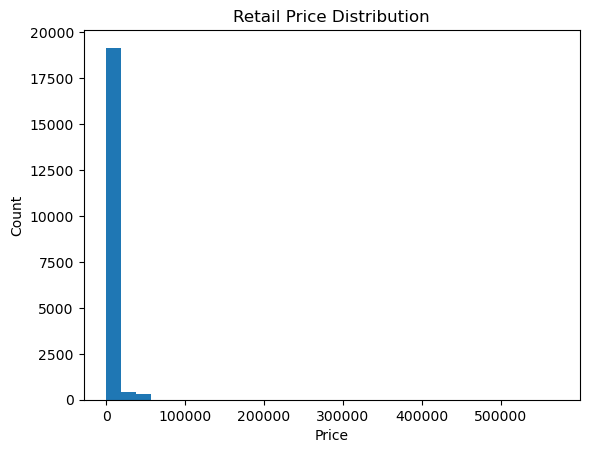

In [6]:
plt.figure()
plt.hist(df['retail_price'], bins=30)
plt.title("Retail Price Distribution")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()

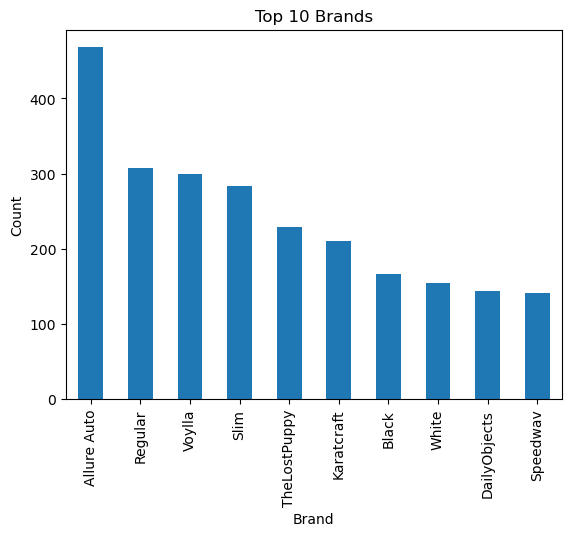

In [7]:
top_brands = df['brand'].value_counts().head(10)

plt.figure()
top_brands.plot(kind='bar')
plt.title("Top 10 Brands")
plt.xlabel("Brand")
plt.ylabel("Count")
plt.show()

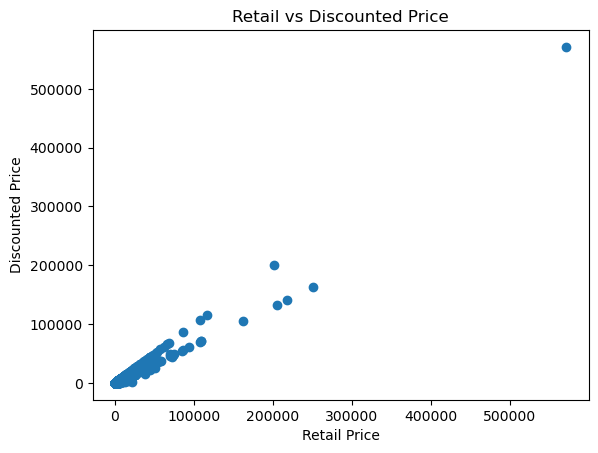

In [8]:
plt.figure()
plt.scatter(df['retail_price'], df['discounted_price'])
plt.title("Retail vs Discounted Price")
plt.xlabel("Retail Price")
plt.ylabel("Discounted Price")
plt.show()

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Features and target
X = df[['retail_price']]
y = df['discounted_price']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Model
model = LinearRegression()
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

print("Sample Predictions:")
print(y_pred[:5])

Sample Predictions:
[ 897.67385045  370.01681822  224.93139769 1180.54989384  126.85689554]


In [10]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)

Mean Squared Error: 2054742.8060441543


In [11]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R2 Score (Accuracy):", r2)

Mean Squared Error: 2054742.8060441543
R2 Score (Accuracy): 0.9604584061491185
